## Overview

MiTo infers clonal ancestries from naturally occurring mtDNA variation. This tutorial
walks the four steps of a run, on simulated data so that it can be executed anywhere:

1. an **Allele Frequency Matrix** (AFM), the `AnnData` object every function consumes,
2. **cell and variant filtering** (`mt.pp`), which decides which MT-SNVs are lineage
   markers and genotypes the cells,
3. a **phylogeny** in mtDNA mutational space (`mt.tl.build_tree`),
4. **clonal annotation** (`mt.tl.annotate_clones`) and visualisation (`mt.pl`).

**N.B.** a working MiTo installation is a prerequisite. See the
[installation guide](https://mito.readthedocs.io/en/latest/installation.html).


## Setup

In [1]:
import matplotlib.pyplot as plt
import mito as mt

mt.__version__

'0.3.0'

## 1. The Allele Frequency Matrix

On real data the AFM is built from the output of a pre-processing pipeline
([nf-MiTo](https://github.com/andrecossa5/nf-MiTo)) with a single call:

```python
afm = mt.io.make_afm(
    'path/to/tables',            # maegatk / mgatk tables, or RedeemV output
    path_meta='cells_meta.csv',  # optional: restricts to annotated cells
    sample='MDA_clones',
    scLT_system='MAESTER',       # 'MAESTER', 'mtscATAC' or 'ReDeeM'
    pp_method='maegatk',         # 'maegatk', 'mgatk' or 'redeem-v'
)
```

Whatever the assay, the object always holds the same things: allele frequencies in `.X`,
alternative allele counts in `.layers['AD']`, the coverage of each variant's site in
`.layers['DP']` (defined for every cell, so that "covered, no alternative read" is
distinguishable from "not covered"), and `pos` / `ref` / `alt` in `.var`.

Here we simulate one instead: 8 clones, each marked by its own MT-SNVs, plus noise.

**N.B.** an AFM written by MiTo < 0.3 has a different layout; convert it once with
`mt.io.migrate_afm(afm)`.


In [2]:
afm = mt.ut.simulate_afm(
    n_cells=500, n_clones=8, n_root_clones=8, max_depth=1,
    frac_double_variants=.3, frac_noisy_variants=.2,
    mean_coverage=200, mean_molecules=40, af_beta=(3, 57), af_beta_min=.04,
    random_seed=1234,
)
afm

AnnData object with n_obs × n_vars = 500 × 12
    obs: 'clone', 'mean_site_coverage', 'median_target_site_coverage', 'frac_target_site_covered', 'nUMIs'
    var: 'pos', 'ref', 'alt', 'clone_of_origin', 'clade', 'n_clones_carrying', 'depth', 'is_noise', 'quality'
    uns: 'scLT_system', 'pp_method', 'simulation'
    layers: 'AD', 'DP', 'genotype', None (.X)

## 2. Cell and variant filtering

`mt.pp.filter_cells` keeps the cells with enough MT coverage to be genotyped, and
`mt.pp.filter_afm` runs the variant pipeline: candidate MT-SNVs from their read
statistics, per-cell genotyping against each variant's own error rate, a clonality test
on the cell kNN graph, a signal-over-background filter, and the character filters the
phylogeny needs. Both modify the object in place, as `scanpy` functions do.

The parameters worth turning are `qc_alpha` (which sets the smallest clone that can be
kept), `geno_alpha`, `min_snr` and `impute`; everything else has a documented default,
and the individual stages are available as `mt.pp` functions of their own.


In [3]:
mt.pp.filter_cells(afm, cell_filter='filter2')
mt.pp.filter_afm(afm)
afm

2026-09-18 16:37:59,396 - INFO - scLT system: MAESTER


2026-09-18 16:37:59,400 - INFO - Filtered cells (median target site coverage >=25, covered sites >=0.75): 500


2026-09-18 16:37:59,404 - INFO - Filter AFM: MAESTER / maegatk, n cells=500, n MT-SNVs=12


2026-09-18 16:37:59,404 - INFO - Restrict to MT-gene bodies: True


2026-09-18 16:37:59,416 - INFO - quality filter: n cells=478, n MT-SNVs=12


...

2026-09-18 16:37:59,763 - INFO - Use the genotypes in the bin layer.


2026-09-18 16:37:59,763 - INFO - Compute distances: ncores=8, metric=weighted_jaccard.


2026-09-18 16:37:59,769 - INFO - Final afm: n cells=461, n characters=10


2026-09-18 16:37:59,769 - INFO - AFM filtering complete: 0.37 s


AnnData object with n_obs × n_vars = 461 × 10
    obs: 'clone', 'mean_site_coverage', 'median_target_site_coverage', 'frac_target_site_covered', 'nUMIs', 'n_characters', 'n_imputed'
    var: 'pos', 'ref', 'alt', 'clone_of_origin', 'clade', 'n_clones_carrying', 'depth', 'is_noise', 'quality', 'error_rate', 'n_carriers', 'n_imputed', 'prevalence', 'snr', 'mean_af', 'mean_cov', 'n_cells', 'median_af_in_positives', 'mean_AD_in_positives', 'mean_DP_in_positives'
    uns: 'scLT_system', 'pp_method', 'simulation', 'mito', 'distances'
    obsp: 'distances'
    layers: 'AD', 'DP', 'genotype', None (.X), 'bin', 'imputed'

What each stage removed is recorded on the object, together with the parameters it
ran with — `.uns['mito']` is the whole history of the AFM.

In [4]:
afm.uns['mito']['filter_afm']['flow']

,stage,n_vars_in,n_vars_out
0,quality filter,12,12
1,candidate filter,12,12
2,known artefacts,12,12
3,clonality filter,12,11
4,signal-to-background filter,11,11
5,prevalence and call-count filters,11,11
6,compatibility filter,11,10


## 3. Phylogeny

Cell-cell distances in mutational space are computed by `filter_afm` (weighted Jaccard
over the genotypes), so the tree only has to be solved.

In [5]:
tree = mt.tl.build_tree(afm, solver='UPMGA')
tree

2026-09-18 16:37:59,777 - INFO - Use precomputed distances: metric=weighted_jaccard, layer=bin


2026-09-18 16:37:59,778 - INFO - Build tree: metric=weighted_jaccard, solver=UPMGA


## 4. Clones

`mt.tl.annotate_clones` cuts the tree where the characters pay for the split: a clade is
subdivided only if its children carry markers specific against their siblings. A cell
whose own calls are not corroborated by its neighbourhood is left `unassigned` rather
than forced into the nearest clade.

In [6]:
mt.tl.annotate_clones(tree, afm)
afm.obs['MiTo_clone'].value_counts()

2026-09-18 16:38:00,655 - INFO - Clonal annotation: 8 clones, 461/461 cells assigned (100.0%)


MiTo_clone
MT-1    118
MT-2     76
MT-3     68
MT-4     61
MT-5     49
MT-6     36
MT-7     31
MT-8     22
Name: count, dtype: int64

Each clone, its size, the tree node it was cut at and its marker MT-SNVs:

In [7]:
afm.uns['mito']['annotate_clones']['clones']

,n_cells,node,markers
clone,,,
MT-1,118,cassiopeia_internal_node44f323905f3944d80ca47510,2638_C>G
MT-2,76,cassiopeia_internal_nodef717a616538c576f908c3c01,4143_C>T
MT-3,68,cassiopeia_internal_nodeb07a5a23d9616710b9df4b37,2352_T>C
MT-4,61,cassiopeia_internal_node186e44abe9e9ef2dd7b0d00f,5420_A>T;6656_A>C
MT-5,49,cassiopeia_internal_node842fad6b76ac5396db01ca12,9053_C>G;12851_A>G
MT-6,36,cassiopeia_internal_nodecdf5be537c763476e47ceaa6,4624_C>T
MT-7,31,cassiopeia_internal_node8b2a9a8afbbb8461d571be90,2169_G>T
MT-8,22,cassiopeia_internal_node41c9cb3bef6842c125eab74e,3089_G>A


Since the data are simulated, the true clone of every cell is known, and the
inference can be scored directly:

In [8]:
labels = afm.obs['MiTo_clone'].astype(str)
assigned = labels != 'unassigned'

print(f'cells assigned: {assigned.mean():.1%}')
print(f'clones found:   {labels[assigned].nunique()} of {afm.obs["clone"].nunique()}')
print(f'ARI:            {mt.ut.custom_ARI(afm.obs["clone"].astype(str)[assigned], labels[assigned]):.3f}')

cells assigned: 100.0%
clones found:   8 of 8
ARI:            1.000


## 5. Visualisation

Annotations are named once in `annot`, whether they live in the cell metadata or among
the characters, and their colours come from `cmaps`.

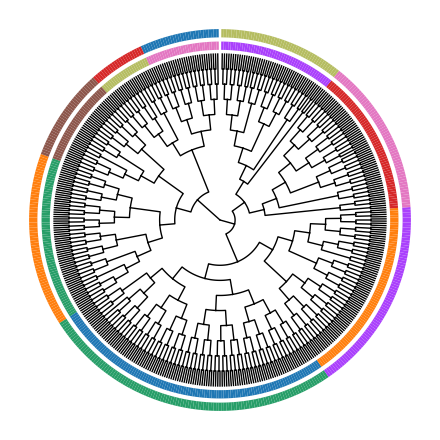

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
mt.pl.plot_tree(tree, annot=['MiTo_clone', 'clone'], ax=ax)
fig.tight_layout()
plt.show()

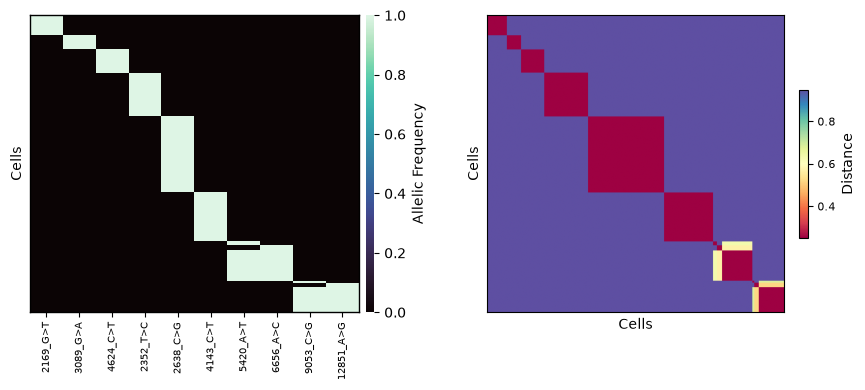

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
mt.pl.heatmap_variants(afm, tree=tree, layer='bin', vmax=1, ax=axs[0])
mt.pl.heatmap_distances(afm, tree=tree, ax=axs[1])
fig.tight_layout()
plt.show()

2026-09-18 16:38:01,366 - INFO - Use bin layer


2026-09-18 16:38:01,367 - INFO - Use precomputed distances


2026-09-18 16:38:02,989 - INFO - UMAP spectral init does not support metric "weighted_jaccard": using "euclidean". Cell-cell distances are unaffected -- the kNN graph is precomputed.


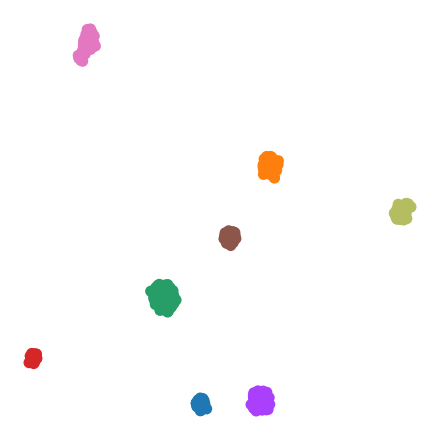

In [11]:
mt.pp.reduce_dimensions(afm, method='UMAP')

fig, ax = plt.subplots(figsize=(4.5, 4.5))
mt.pl.draw_embedding(afm, feature='MiTo_clone', legend=True, ax=ax)
fig.tight_layout()
plt.show()

## Outlook

For a worked example on real MAESTER data with ground truth clonal labels, see the
[Ground Truth Benchmark](benchmark.ipynb) tutorial.
